# 05 · Neural-guided program search
### From handcrafted UCT bonuses to learned action policies and value estimates

**Question:** Could a model predict which *legal next program extension* deserves scarce evaluation budget—without replacing the interpreter or hiding how search works?

In **02** we represented programs as typed hypotheses. In **03** we weighted plausible programs. In **04** we allocated search effort by count-based optimism (UCB / UCT). Now we learn a task-conditioned **policy** and **value** from previously solved *training tasks* and use them to guide an otherwise transparent tree search.

**Route:** partial programs → state features → expert demonstrations → supervised policy → value regression → leakage-safe splits → guided PUCT search → matched-budget comparisons → distribution shift / ablations → interface to your Grammar-UCT system.

This notebook deliberately uses a small, fully enumerable *synthetic program grammar*. All values are known, so we can independently test our claims. It is **not** an ARC benchmark, and the synthetic "expert" is not an algorithm for solving hidden ARC tasks.

**Prerequisites:** NumPy, Matplotlib only; no PyTorch, GPU, or internet required. Predict before running each code cell, then try the exercises.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass,field
from itertools import product
SEED=5026
rng=np.random.default_rng(SEED)
plt.rcParams.update({'figure.figsize':(9,3.6),'axes.grid':True,'grid.alpha':.18})
print('Lesson 05: symbolic execution remains exact; statistical models guide search.')

Lesson 05: symbolic execution remains exact; statistical models guide search.


## 1 · The simplest useful conditional search problem

A task has a hidden three-step target program over four tokens: **A, B, C, D**. Think of these as opaque, typed symbolic operations. For a task with context vector $x$, the target is chosen by a deterministic *teaching generator*. The learner sees the context, not the target, during search.

A partial program $p=(a_1,\ldots,a_d)$ is a search state, and an action appends one legal token. A complete program is successful exactly when its tokens equal the hidden target. There are $4^3=64$ complete programs.

We use two context features to define target steps. Each step depends on different context-derived decisions so that learning meaningful **task-conditioning** beats a single global favorite action.

**Predict:** Does the best next action depend only on depth, or also on the task context?

**What this toy actually tests:** A–D have no grid semantics. Search receives an exact-match reward from a synthetic evaluator; the hidden target is not an input to the policy. Different held-out contexts can produce the **same target sequence** as training contexts, so this is new-context generalization, not unseen-program or compositional generalization. Section 7 evaluates correct expert prefixes (teacher forcing); search may visit incorrect prefixes absent from policy training.

Input features per search state: 15


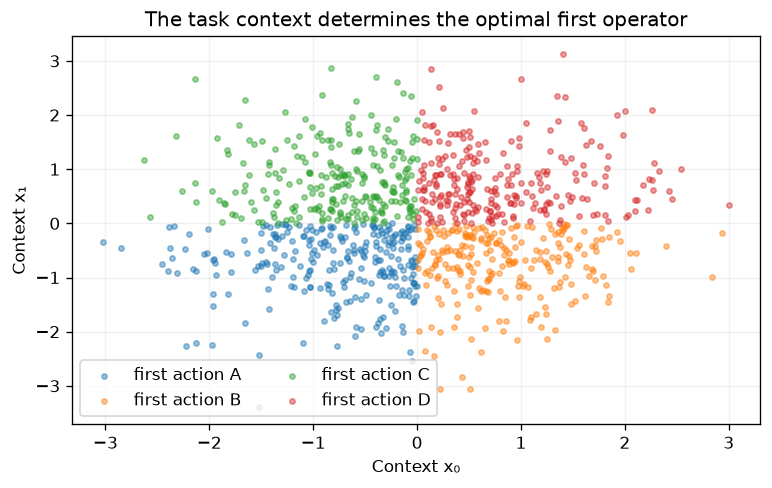

In [2]:
OPS=('A','B','C','D'); K=len(OPS); DEPTH=3
def make_tasks(n,seed):
    g=np.random.default_rng(seed)
    return g.normal(size=(n,2))
def task_target(x):
    x0,x1=map(float,x)
    a0=int(x0>0)+2*int(x1>0)
    a1=(a0+int(x0*x1>0)+1)%K
    a2=(a1+int(abs(x0)>abs(x1))+1)%K
    return (a0,a1,a2)
def task_features(x,path):
    # Dense, manually specified features are a stand-in for embeddings in lesson 06.
    d=len(path)
    onehot=np.zeros((DEPTH,K))
    for j,a in enumerate(path):onehot[j,a]=1.
    return np.r_[np.asarray(x),float(d)/DEPTH,onehot.ravel()]
train_x=make_tasks(1000,SEED)
val_x=make_tasks(250,SEED+1)
test_x=make_tasks(250,SEED+2)
assert len({tuple(z) for z in train_x}.intersection({tuple(z) for z in test_x}))==0
assert all(len(task_target(x))==DEPTH for x in train_x)
fig,ax=plt.subplots(figsize=(7.4,4.2))
groups=np.array([task_target(x)[0] for x in train_x])
for i in range(K):
    pts=train_x[groups==i]
    ax.scatter(pts[:,0],pts[:,1],s=10,alpha=.45,label=f'first action {OPS[i]}')
ax.set(xlabel='Context x₀',ylabel='Context x₁',title='The task context determines the optimal first operator')
ax.legend(ncol=2);plt.show()
print('Input features per search state:',len(task_features(train_x[0],())))

## 2 · Policy targets: a distribution over legal actions

A policy $\pi_\theta(a\mid x,p)$ outputs a distribution across possible next operations. In a solved synthetic task, a demonstration label is the next step of its successful program. We train with **cross-entropy**:

$$\mathcal L_{policy}=-\frac1N\sum_i\log \pi_\theta(a_i^*\mid x_i,p_i).$$

This is supervised imitation, *not reinforcement learning*. We know correct steps only because the teaching generator supplies them. On real ARC work, solved trajectories, verified alternative programs, and search history would provide imperfect and potentially biased targets.

The policy does not directly execute operations: the interpreter and grammar retain that responsibility. **Predict:** If an expert demonstration is not unique, is a one-hot next-action label necessarily the only defensible target?

Train policy examples: (3000, 15) validation: (750, 15) test: (750, 15)


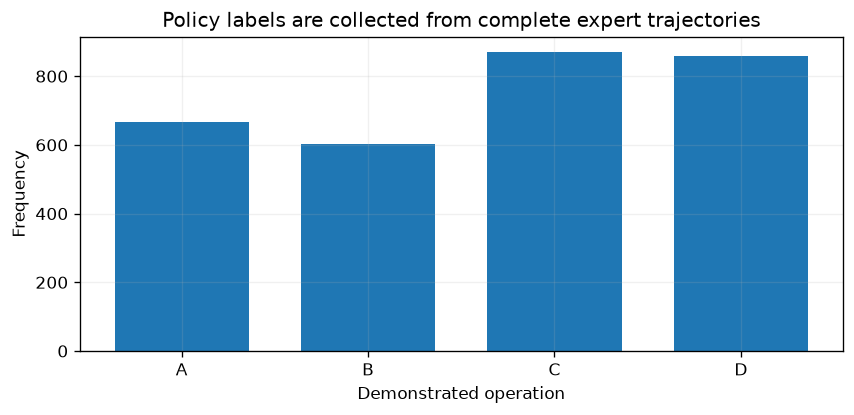

In [3]:
def build_policy_data(tasks):
    xx=[];yy=[]
    for x in tasks:
        target=task_target(x)
        for depth in range(DEPTH):
            xx.append(task_features(x,target[:depth]))
            yy.append(target[depth])
    return np.asarray(xx),np.asarray(yy,dtype=int)
Xtr,Ytr=build_policy_data(train_x)
Xva,Yva=build_policy_data(val_x)
Xte,Yte=build_policy_data(test_x)
print('Train policy examples:',Xtr.shape,'validation:',Xva.shape,'test:',Xte.shape)
fig,ax=plt.subplots(figsize=(8.2,3.4))
ax.hist(Ytr,bins=np.arange(K+1)-.5,rwidth=.72)
ax.set(xticks=range(K),xticklabels=OPS,xlabel='Demonstrated operation',ylabel='Frequency',
       title='Policy labels are collected from complete expert trajectories');plt.show()

## 3 · Build a tiny neural policy with transparent NumPy gradients

We implement a one-hidden-layer tanh network. Scores (logits) are converted to probabilities by a numerically stable softmax:

$$h=\tanh(XW_1+b_1),\quad z=hW_2+b_2,\quad \pi_a=\frac{e^{z_a}}{\sum_b e^{z_b}}.$$

The output gradient for softmax cross-entropy is $(\pi-\text{onehot}(y))/N$. This is the same chain rule from lesson 00; the output meaning has changed from numeric prediction to a categorical search preference.

**Predict:** What happens if softmax logits differ by a very large constant added equally to every class?

Validation action accuracy: 0.995


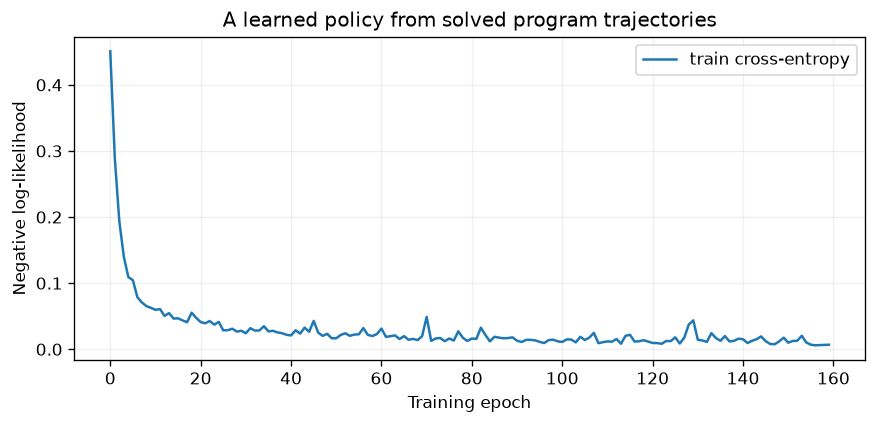

In [4]:
def softmax(logits):
    z=np.asarray(logits)-np.max(logits,axis=-1,keepdims=True)
    p=np.exp(z)
    return p/p.sum(axis=-1,keepdims=True)
def init_model(in_dim,out_dim,hidden=24,seed=0):
    g=np.random.default_rng(seed)
    return {'W1':g.normal(0,.23,(in_dim,hidden)), 'b1':np.zeros(hidden),
            'W2':g.normal(0,.23,(hidden,out_dim)), 'b2':np.zeros(out_dim)}
def network_forward(p,x,classification=True):
    h=np.tanh(x@p['W1']+p['b1'])
    z=h@p['W2']+p['b2']
    return (softmax(z) if classification else z),h
def policy_loss_grad(p,x,y,weight_decay=0.):
    probs,h=network_forward(p,x)
    n=len(y)
    loss=-np.log(np.maximum(probs[np.arange(n),y],1e-12)).mean()
    dz=probs.copy();dz[np.arange(n),y]-=1;dz/=n
    grads={'W2':h.T@dz+weight_decay*p['W2'],'b2':dz.sum(axis=0)}
    dh=(dz@p['W2'].T)*(1-h*h)
    grads['W1']=x.T@dh+weight_decay*p['W1']
    grads['b1']=dh.sum(axis=0)
    loss+=.5*weight_decay*(np.sum(p['W1']**2)+np.sum(p['W2']**2))
    return float(loss),grads
def train_network(p,grad_fn,x,y,epochs=200,rate=.035,batch=128,seed=0):
    gen=np.random.default_rng(seed)
    m={k:np.zeros_like(v) for k,v in p.items()}
    v={k:np.zeros_like(q) for k,q in p.items()}
    step=0;history=[]
    for epoch in range(epochs):
        for inds in np.array_split(gen.permutation(len(x)),max(1,int(np.ceil(len(x)/batch)))):
            _,gr=grad_fn(p,x[inds],y[inds]);step+=1
            for k in p:
                m[k]=.9*m[k]+.1*gr[k]
                v[k]=.999*v[k]+.001*(gr[k]*gr[k])
                p[k]-=rate*(m[k]/(1-.9**step))/(np.sqrt(v[k]/(1-.999**step))+1e-8)
        history.append(grad_fn(p,x,y)[0])
    return np.array(history)
policy=init_model(Xtr.shape[1],K,seed=SEED)
hist=train_network(policy,policy_loss_grad,Xtr,Ytr,epochs=160,seed=SEED)
fig,ax=plt.subplots(figsize=(8.5,3.5))
ax.plot(hist,label='train cross-entropy')
ax.set(xlabel='Training epoch',ylabel='Negative log-likelihood',
       title='A learned policy from solved program trajectories');ax.legend();plt.show()
print('Validation action accuracy:',round(float(np.mean(network_forward(policy,Xva)[0].argmax(1)==Yva)),3))
assert np.allclose(softmax(np.array([[2.,3.]])),softmax(np.array([[1202.,1203.]])))

## 4 · Verify the gradient; do not trust a loss curve alone

A finite difference approximates $\partial L/\partial w$ by perturbing one weight: $[L(w+\epsilon)-L(w-\epsilon)]/(2\epsilon)$. We compare to the analytic backpropagation gradient on a small batch. A model can appear to learn despite an implementation bug; this check tests a local mathematical invariant.

**Predict:** Why do we use a fresh randomly initialized network rather than only checking after training has nearly converged?

In [5]:
check=init_model(Xtr.shape[1],K,hidden=7,seed=7)
small_x=Xtr[:12];small_y=Ytr[:12]
_,gg=policy_loss_grad(check,small_x,small_y)
errs=[]
for name,idx in [('W1',(0,0)),('W1',(2,4)),('b1',(3,)),('W2',(2,1)),('b2',(1,))]:
    eps=1e-5
    check[name][idx]+=eps;up=policy_loss_grad(check,small_x,small_y)[0]
    check[name][idx]-=2*eps;dn=policy_loss_grad(check,small_x,small_y)[0]
    check[name][idx]+=eps
    fd=(up-dn)/(2*eps);errs.append(abs(fd-gg[name][idx]))
print('Max finite-difference gradient error:',max(errs))
assert max(errs)<1e-7

Max finite-difference gradient error: 1.3455727417704955e-11


## 5 · Value learning: what does a partial program promise?

A value model $V_\phi(x,p)$ tries to estimate the expected utility of continuing from a prefix under a *specified continuation policy and budget*. Unlike a policy, it outputs **one scalar**, not an action distribution.

For a controlled demonstration we define a *random-rollout value*: the chance that uniformly random remaining actions complete the true target, provided the current prefix is correct. With branching factor $K$ and remaining depth $r$:

$$V^*(x,p)=\mathbf 1[p\text{ matches target prefix}]K^{-r}.$$

This is **not** the probability that a fixed prefix is intrinsically correct. It is the expected success of one random completion from that prefix. It gives a supervised regression target that we can independently calculate.

**Predict:** Why does the correct root prefix have value $1/64$, whereas the complete correct program has value $1$?

Value examples: (17000, 15) target mean: 0.015625


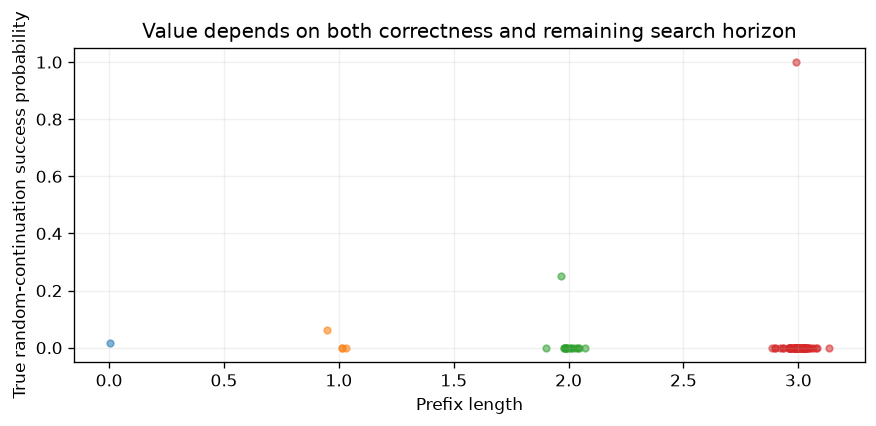

In [6]:
def rollout_value(x,path):
    target=task_target(x)
    return (K**(-(DEPTH-len(path)))) if tuple(path)==target[:len(path)] else 0.
def build_value_data(tasks):
    xx=[];yy=[]
    for x in tasks:
        for d in range(DEPTH+1):
            for path in product(range(K),repeat=d):
                xx.append(task_features(x,path))
                yy.append(rollout_value(x,path))
    return np.asarray(xx),np.asarray(yy)[:,None]
Vxtr,Vytr=build_value_data(train_x[:200])
Vxva,Vyva=build_value_data(val_x[:80])
assert np.isclose(rollout_value(train_x[0],()),1/64)
assert np.isclose(rollout_value(train_x[0],task_target(train_x[0])),1)
print('Value examples:',Vxtr.shape,'target mean:',float(Vytr.mean()))
fig,ax=plt.subplots(figsize=(8.5,3.4))
for d in range(DEPTH+1):
    y=[rollout_value(train_x[0],p) for p in product(range(K),repeat=d)]
    ax.scatter(np.full(len(y),d)+np.random.default_rng(d).normal(0,.04,len(y)),y,s=16,alpha=.55)
ax.set(xlabel='Prefix length',ylabel='True random-continuation success probability',
       title='Value depends on both correctness and remaining search horizon');plt.show()

## 6 · Train the value estimator and inspect its limitations

The same hidden layer supports regression with a linear output. We use mean squared error. For scalar predictions, the derivative of half-MSE with respect to output is $(\hat v-v)/N$.

A value estimate may be inaccurate on rare high-value leaves because most enumerated prefixes are incorrect and have target value zero. Always inspect errors **by depth and by outcome**, not just a global mean.

**Predict:** Could a value regressor achieve low MSE by predicting nearly zero everywhere while being useless for search?

Value validation RMSE: 0.0859868196972914
Zero-value baseline RMSE: 0.112
depth 0 positive n= 80 RMSE= 0.0496
depth 1 positive n= 80 RMSE= 0.0436
depth 1 zero n= 240 RMSE= 0.0329
depth 2 positive n= 80 RMSE= 0.1042
depth 2 zero n= 1200 RMSE= 0.0397
depth 3 positive n= 80 RMSE= 0.5803
depth 3 zero n= 5040 RMSE= 0.0629


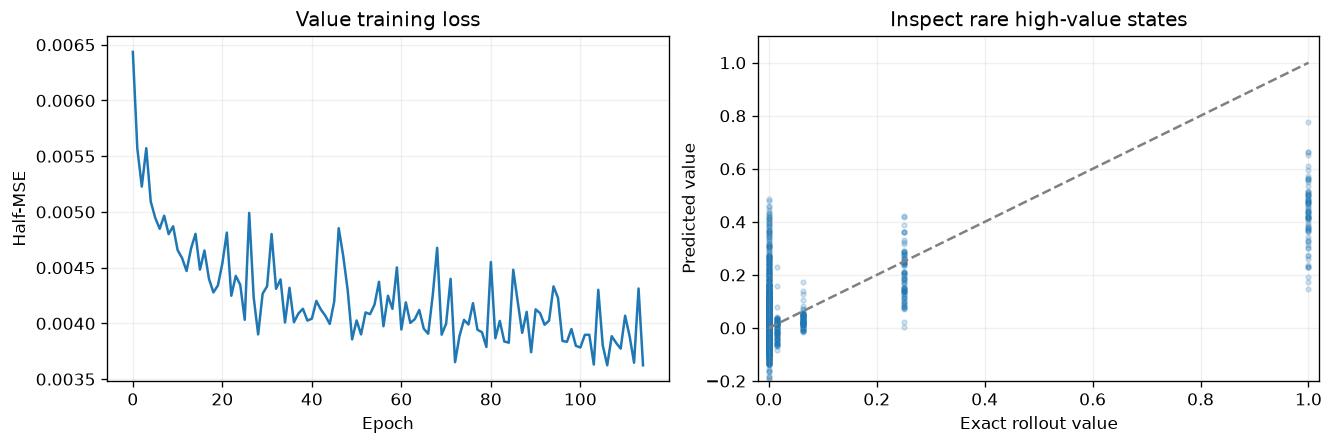

In [7]:
def value_loss_grad(p,x,y,weight_decay=0.):
    pred,h=network_forward(p,x,classification=False)
    err=pred-y;n=len(x)
    loss=.5*np.mean(err**2)
    dz=err/n
    gr={'W2':h.T@dz+weight_decay*p['W2'],'b2':dz.sum(axis=0)}
    dh=(dz@p['W2'].T)*(1-h*h)
    gr['W1']=x.T@dh+weight_decay*p['W1']
    gr['b1']=dh.sum(axis=0)
    loss+=.5*weight_decay*(np.sum(p['W1']**2)+np.sum(p['W2']**2))
    return float(loss),gr
value=init_model(Vxtr.shape[1],1,hidden=32,seed=SEED+1)
vh=train_network(value,value_loss_grad,Vxtr,Vytr,epochs=115,rate=.018,seed=SEED+2)
pred,_=network_forward(value,Vxva,classification=False)
print('Value validation RMSE:',float(np.sqrt(np.mean((pred-Vyva)**2))))
fig,axs=plt.subplots(1,2,figsize=(11,3.6),layout='constrained')
axs[0].plot(vh);axs[0].set(title='Value training loss',xlabel='Epoch',ylabel='Half-MSE')
axs[1].scatter(Vyva,pred[:,0],s=8,alpha=.2)
axs[1].plot([0,1],[0,1],ls='--',color='gray')
axs[1].set(xlim=(-.02,1.02),ylim=(-.2,1.1),xlabel='Exact rollout value',ylabel='Predicted value',
           title='Inspect rare high-value states');plt.show()
assert np.isfinite(pred).all()
zero_rmse=float(np.sqrt(np.mean(Vyva**2)))
print('Zero-value baseline RMSE:',round(zero_rmse,4))
for d in range(DEPTH+1):
    depth_mask=np.isclose(Vxva[:,2],d/DEPTH)
    for label, outcome_mask in [('positive',Vyva[:,0]>0),('zero',Vyva[:,0]==0)]:
        keep=depth_mask & outcome_mask
        if keep.any():
            print('depth',d,label,'n=',int(keep.sum()),
                  'RMSE=',round(float(np.sqrt(np.mean((pred[keep]-Vyva[keep])**2))),4))


## 7 · Leakage-safe task splits and policy accuracy by depth

We separated tasks *before* generating multiple prefix rows. Otherwise, nearly identical prefixes from one task could appear in both train and test, leaking the hidden program.

We now plot held-out next-action accuracy separately by prefix depth. We compare it against a uniform $1/K$ baseline. Overall accuracy can conceal an easy first action and a difficult second or third action.

**Predict:** Why does holding out rows, rather than task identities, inflate confidence in a model for new tasks?

Held-out action accuracies: [0.992 1.    0.996]


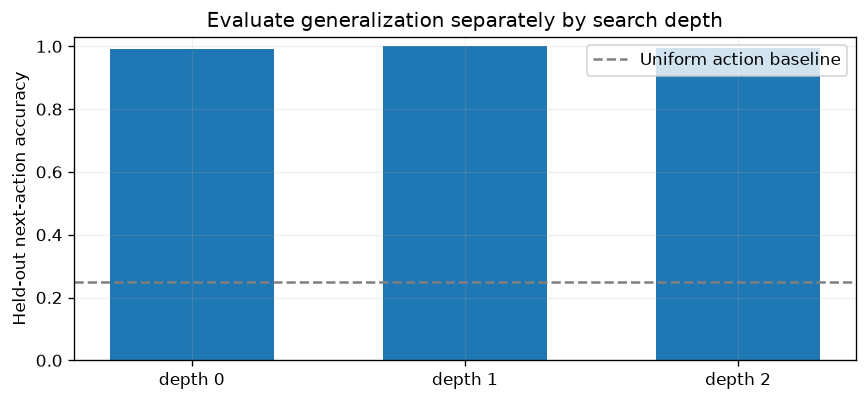

In [8]:
probs,_=network_forward(policy,Xte)
depths=np.tile(np.arange(DEPTH),len(test_x))
acc=np.array([np.mean(probs[depths==d].argmax(1)==Yte[depths==d]) for d in range(DEPTH)])
fig,ax=plt.subplots(figsize=(8.4,3.5))
ax.bar(range(DEPTH),acc,width=.6)
ax.axhline(1/K,color='gray',ls='--',label='Uniform action baseline')
ax.set(xticks=range(DEPTH),xticklabels=[f'depth {d}' for d in range(DEPTH)],
       ylim=(0,1.03),ylabel='Held-out next-action accuracy',
       title='Evaluate generalization separately by search depth');ax.legend();plt.show()
print('Held-out action accuracies:',np.round(acc,3))

## 8 · From learned action probabilities to PUCT

The policy can guide search by changing the exploration bonus. A common **PUCT-style** score is:

$$S(s,a)=Q(s,a)+c_{puct}P_\theta(a\mid s)\frac{\sqrt{N(s)}}{1+N(s,a)}.$$

Compared with UCT's generic optimism, $P_\theta$ redistributes exploration toward actions that look promising in the task context. The prior **must be normalized over legal actions**, not an unconstrained output over impossible grammar moves.

**Important:** PUCT is an algorithmic *selection rule*, not a claim that the learned policy is correct. If the prior assigns extremely little weight to a necessary action, guided search can be worse than uniform or UCT. Root Dirichlet noise and other mechanisms are optional exploration devices; our first implementation omits them for transparency.

**Predict:** If two actions have identical $Q$ and visit counts, which receives a higher PUCT score?

In [9]:
@dataclass
class SearchNode:
    path:tuple
    visits:int=0
    reward_sum:float=0.
    children:dict=field(default_factory=dict)
    @property
    def mean(self):
        return self.reward_sum/self.visits if self.visits else 0.
def policy_prior(x,path,mode='learned'):
    if mode=='uniform':return np.full(K,1/K)
    features=task_features(x,path)[None,:]
    p=network_forward(policy,features)[0][0]
    p=np.clip(p,1e-8,None)
    return p/p.sum()
def choose_puct(node,x,mode,c=1.):
    prior=policy_prior(x,node.path,mode)
    N=node.visits
    return max(range(K),key=lambda a:
        node.children[a].mean+
        c*prior[a]*np.sqrt(max(1,N))/(1+node.children[a].visits))
print('Example learned policy:',np.round(policy_prior(test_x[0],()),3))
assert np.isclose(policy_prior(test_x[0],()).sum(),1.)

Example learned policy: [0. 0. 1. 0.]


## 9 · A complete transparent guided-search loop

We search tree prefixes, expanding one new child on a visit, then complete to a terminal program by sampling from either the learned policy or a uniform rollout. The **interpreter/terminal evaluator remains exact**: success is a complete token match, not a high network score.

We keep two independent controls:
- `selection`: count-based UCT or prior-weighted PUCT;
- `rollout`: uniform or learned completion.

This supports an ablation: did gains come from better tree selection, better rollouts, or both?

**Budget definition:** one complete terminal candidate execution per iteration. Repeated candidates **still consume budget**, just as a real computation would without cache hits. We record exact discovery on held-out tasks, not average model confidence.

**Implementation detail:** this is a PUCT-style hybrid: it forces every missing child to be expanded before revisiting children with the PUCT formula. Standard all-child PUCT can revisit a high-prior child while another child remains unvisited. Our forced expansion changes behavior at small budgets and should not be mistaken for a literal AlphaZero implementation.

In [10]:
def guided_search(x,budget=45,seed=0,selection='uct',rollout='uniform',c=1.1,return_trace=False):
    gen=np.random.default_rng(seed);root=SearchNode(())
    target=task_target(x)
    first=None;traces=[]
    for iteration in range(1,budget+1):
        node=root;ancestors=[root]
        while len(node.path)<DEPTH:
            missing=[a for a in range(K) if a not in node.children]
            if missing:
                if selection=='puct':
                    prior=policy_prior(x,node.path)
                    weights=prior[missing]/prior[missing].sum()
                    action=int(gen.choice(missing,p=weights))
                else:
                    action=int(gen.choice(missing))
                new=SearchNode(node.path+(action,))
                node.children[action]=new;node=new;ancestors.append(node);break
            if selection=='uct':
                action=max(range(K),key=lambda a:node.children[a].mean+
                           c*np.sqrt(np.log(max(node.visits,2))/node.children[a].visits))
            elif selection=='puct':
                action=choose_puct(node,x,'learned',c=c)
            else:raise ValueError(selection)
            node=node.children[action];ancestors.append(node)
        path=list(node.path)
        while len(path)<DEPTH:
            if rollout=='uniform':
                action=int(gen.integers(K))
            elif rollout=='learned':
                prior=policy_prior(x,tuple(path))
                action=int(gen.choice(K,p=prior))
            else:raise ValueError(rollout)
            path.append(action)
        reward=float(tuple(path)==target)
        for n in ancestors:n.visits+=1;n.reward_sum+=reward
        traces.append(tuple(path))
        if reward and first is None:first=iteration
    assert root.visits==budget
    if return_trace:return first,traces,root
    return first
example=test_x[0]
for select,roll in [('uct','uniform'),('puct','uniform'),('puct','learned')]:
    hit=guided_search(example,budget=100,seed=100,selection=select,rollout=roll)
    print(f'{select:5s} / {roll:7s} | first exact discovery:',hit)
assert guided_search(example,budget=10,seed=3,return_trace=True)[2].visits==10

uct   / uniform | first exact discovery: 7
puct  / uniform | first exact discovery: 9
puct  / learned | first exact discovery: 1


## 10 · Compare methods at matched executable-program budgets

We estimate discovery probability over **held-out tasks and multiple random seeds**. Both tree methods receive the same budget of complete executions. This is more meaningful than comparing loss curves alone.

The methods are:
1. UCT selection + uniform rollout.
2. PUCT selection + uniform rollout.
3. PUCT selection + learned rollout.
4. Uniform random enumeration without replacement.
5. Independent policy-only sampling (no tree).
6. A learned **greedy program** baseline (one prediction, no tree search).

The greedy baseline counts as one program execution; it is included to clarify the difference between *direct prediction* and *search*. It is not budget-matched beyond that one evaluation.

**Predict:** Can guided search perform worse than UCT even when overall action classification accuracy is above chance?

Greedy complete-program accuracy (one execution): 1.0
UCT + uniform budget 45 success fraction 0.536
PUCT + uniform budget 45 success fraction 1.0
PUCT + policy rollout budget 45 success fraction 1.0
Shuffled enumeration budget 45 success fraction 0.764
Policy-only sampling budget 45 success fraction 1.0


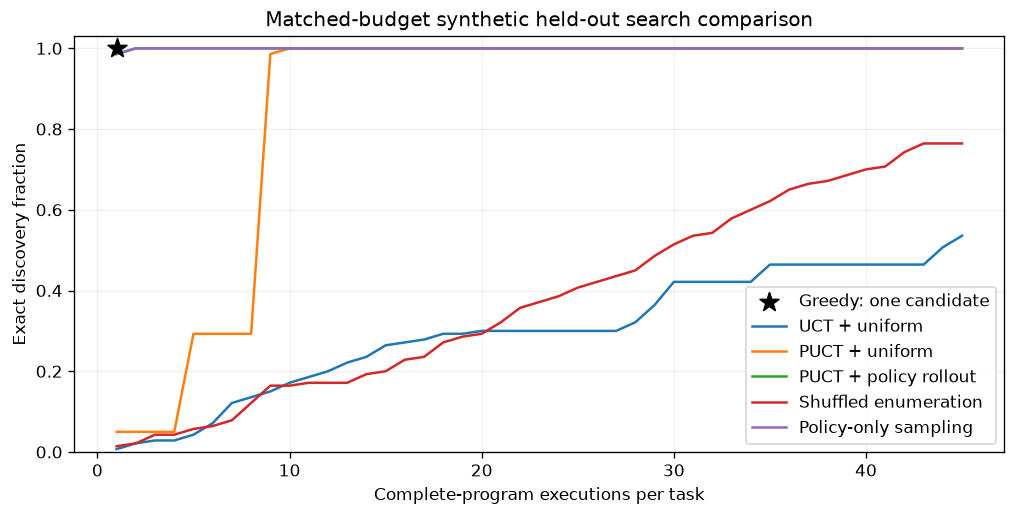

In [11]:
budget=45
tasks=test_x[:70]
config=[('UCT + uniform','uct','uniform'),
        ('PUCT + uniform','puct','uniform'),
        ('PUCT + policy rollout','puct','learned')]
curves={}
for name,selection,rollout in config:
    hits=[guided_search(x,budget=budget,seed=1000+7*i+j,
                        selection=selection,rollout=rollout)
          for i,x in enumerate(tasks) for j in range(2)]
    curves[name]=np.array([np.mean([v is not None and v<=b for v in hits])
                           for b in range(1,budget+1)])
# Strong simple baselines: does the tree add anything beyond the policy?
all_paths=list(product(range(K), repeat=DEPTH))
def direct_candidate(x, gen=None):
    path=()
    while len(path)<DEPTH:
        prior=policy_prior(x,path)
        a=int(np.argmax(prior)) if gen is None else int(gen.choice(K,p=prior))
        path += (a,)
    return path
for baseline in ('Shuffled enumeration', 'Policy-only sampling'):
    hits=[]
    for i,x in enumerate(tasks):
        for j in range(2):
            gen=np.random.default_rng(1000+7*i+j)
            candidates=([all_paths[k] for k in gen.permutation(len(all_paths))[:budget]]
                        if baseline=='Shuffled enumeration'
                        else [direct_candidate(x,gen) for _ in range(budget)])
            hits.append(next((k+1 for k,p in enumerate(candidates) if p==task_target(x)),None))
    curves[baseline]=np.array([np.mean([h is not None and h<=b for h in hits])
                              for b in range(1,budget+1)])
greedy_rate=np.mean([direct_candidate(x)==task_target(x) for x in tasks])
print('Greedy complete-program accuracy (one execution):',round(float(greedy_rate),3))
fig,ax=plt.subplots(figsize=(10,4.5))
ax.scatter([1],[greedy_rate],marker='*',s=140,color='black',label='Greedy: one candidate',zorder=5)
for name,y in curves.items():ax.plot(np.arange(1,budget+1),y,label=name)
ax.set(xlabel='Complete-program executions per task',ylabel='Exact discovery fraction',
       ylim=(0,1.03),title='Matched-budget synthetic held-out search comparison')
ax.legend();plt.show()
for name,y in curves.items():print(name,'budget 45 success fraction',round(float(y[-1]),3))

## 11 · Visualize predictions versus search actions on one task

For a held-out task, examine the learned first-step action probabilities and compare them with the actual first step. Confidence is not proof: a miscalibrated prior can deprioritize the correct branch.

Because our policy is trained from one labeled next step per solved path, it knows nothing about alternative valid programs; in a richer language, many distinct programs can be functionally equivalent. A useful target could instead distribute mass across a set of verified legal actions.

**Predict:** What is the failure mode if the correct action gets a tiny but nonzero probability and the search budget is very small?

**Read the comparison:** policy-only sampling isolates the benefit of learned proposals; PUCT adds adaptive allocation and bookkeeping. Shuffled enumeration never repeats a syntax string, whereas the samplers and tree can. Equal execution counts do not imply equal runtime. If the simple sampler wins here, retain that result: it is evidence that this tiny problem does not justify the tree's extra machinery.

True program: ('C', 'D', 'A')
Top greedy prior action: C


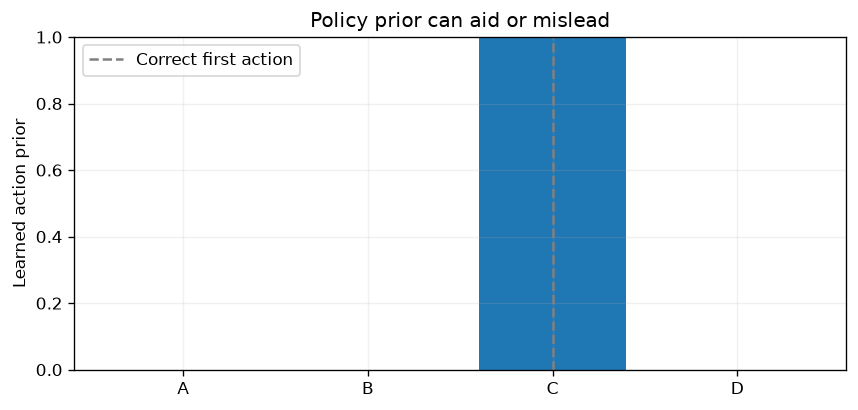

In [12]:
x=test_x[5]
true=task_target(x)
p=policy_prior(x,())
fig,ax=plt.subplots(figsize=(8.3,3.6))
ax.bar(OPS,p)
ax.axvline(true[0],color='gray',ls='--',label='Correct first action')
ax.set(ylabel='Learned action prior',ylim=(0,1),title='Policy prior can aid or mislead')
ax.legend();plt.show()
print('True program:',tuple(OPS[a] for a in true))
print('Top greedy prior action:',OPS[int(np.argmax(p))])

## 12 · Policy imitation is not unbiased supervision

Our expert labels are synthetically generated with full knowledge of the target. In practical neural-guided program synthesis, search traces are **selected samples**: previously used search policies decide which candidate programs are ever observed. Unsuccessful tasks may offer little positive supervision, and an exact fit to training examples may not identify the intended transformation.

A robust collection pipeline should record task ID, split, partial state, legal action set, operator/source choice, execution result, provenance, compute cost, and eventual verified outcome. Crucially, separate:
- *demonstration label* (what the previous solver chose),
- *outcome label* (what happened),
- *counterfactual label* (what might have happened under another action—generally unobserved).

**Do not train from held-out tasks** just because their results were easy to collect. If you tune the policy repeatedly on those tasks, they cease to be a valid final evaluation set.

## 13 · Value-guided search is a separate architectural choice

Our trained value network approximates **uniform-rollout success probability**. If a guided tree uses policy-biased rollouts, those targets no longer refer to the same continuation policy. A value head fitted on one reward/horizon does not automatically estimate another.

A possible leaf evaluation is
$$G=\lambda\,\widehat V(x,p)+(1-\lambda)\,R_{rollout},$$
but then tree statistics reflect a mixture of predicted and observed returns. Measuring true exact solves must remain separate from this internal selection score.

For a clean ablation, do not introduce policy priors, learned value, different rollout behavior, and new stopping rules simultaneously. The experiment above intentionally uses a **learned policy**, but leaves value out of backup; the value network is trained as a transparent separate component.

**Predict:** How could a value network with low overall MSE still systematically deprioritize the unique correct program?

True max predicted value: 0.43915443210861405 | largest predicted wrong-state value: 0.226698930053686


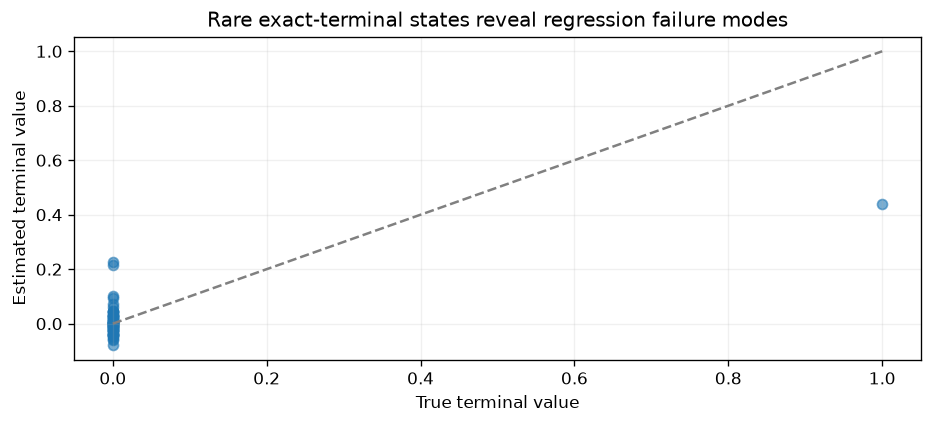

In [13]:
example_x=test_x[4]
paths=list(product(range(K),repeat=DEPTH))
pred,_=network_forward(value,np.array([task_features(example_x,p) for p in paths]),classification=False)
truth=np.array([rollout_value(example_x,p) for p in paths])
fig,ax=plt.subplots(figsize=(9.1,3.5))
ax.scatter(truth,pred[:,0],alpha=.6)
ax.plot([0,1],[0,1],ls='--',color='gray')
ax.set(xlabel='True terminal value',ylabel='Estimated terminal value',
       title='Rare exact-terminal states reveal regression failure modes')
plt.show()
print('True max predicted value:',float(pred[truth==1].max()),
      '| largest predicted wrong-state value:',float(pred[truth==0].max()))

## 14 · What transfers to a real ARC grammar crawler?

A practical bridge from the learning demo to your symbolic environment:

| This notebook | Grammar-UCT counterpart |
|---|---|
| Context vector | Training input/output grids and unsolved ST constraints |
| Prefix `path` | Generated gene lineage / partial composition |
| Candidate action | Legal operation + legal source phenotype + parameters |
| One-hot label | Verified useful next decisions from solved traces |
| Exact terminal reward | Exact demonstration solve and separate held-out test verification |
| Policy prior | Learned distribution over available legal operation/source choices |
| Value estimate | Expected future solve progress under a specified budget and continuation policy |
| PUCT tree | Optional task-local exploration conditioned by learned transferable priors |

**Critical differences:** actual operations have variable arity and variable execution cost; legal source combinations can be enormous; multiple genes can share identical behavior; duplicate and pruning rules affect the available state; and one physical gene may bundle several semantic components. Treat the current fixed-size feature vector as a placeholder for **lesson 06's structure/execution embeddings**.

Measure progress by actual task solves, number of *candidate executions*, accepted generations, wall time, and unseen-task outcomes. One model cannot be judged solely by its action classification accuracy.

## 15 · Exercises

1. Derive the softmax-cross-entropy gradient for one example and explain why logits must be normalized stably.
2. Change task generation so only one action at depth 2 depends on context; which policy input variables become unnecessary?
3. Train a constant global prior from action frequencies, then compare its held-out action accuracy with the conditional policy.
4. Alter the value target to expected reward with two independent uniform rollouts. Derive $1-(1-p)^2$ from the one-rollout success probability $p$.
5. Add a legal-action mask. Specify what happens to zero-probability legal actions during exploration.
6. Implement a *policy-only* rollout sampler and compare with greedy direct prediction at matched candidate counts.
7. Include a wrong-task context shift (rotate the quadrant labels for test contexts only). Quantify how policy guidance degrades.
8. Introduce multiple equally valid target programs, and explain why a one-hot imitation label can be misleading.
9. Implement a simple $\lambda$-mixed leaf score, but retain an independent flag for whether an exact program was executed.
10. Design a fair real ARC experiment that prevents leakage between solved traces, model training, hyperparameter tuning, and final evaluation.

Try at least three experiments before reading solutions.

## 16 · Solutions, boundaries, and what comes next

1. For softmax probability vector $p$ and one-hot target $y$, $\partial\mathcal L/\partial z=p-y$. Subtracting the maximum logit before exponentiating prevents numerical overflow without changing probabilities.
2. Depth one-hot and other prefix information may remain useful; inputs are unnecessary only when the target and model class truly do not depend on them.
3. A global policy cannot represent context-conditional decisions. Do not compare training accuracy to held-out conditional accuracy.
4. For independent Bernoulli success probability $p$, two misses have probability $(1-p)^2$. Hence the chance of at least one hit is $1-(1-p)^2$.
5. Mask illegal actions before normalization. Keep an explicit exploration mechanism when correct legal actions may receive negligible predicted probability.
6. A greedy program gives one candidate. Rollout sampling gives a distribution over candidates: compare equal numbers of full executions.
7. Concept drift can break previously helpful priors. Measure changes under a known shift instead of expecting transfer.
8. Use soft multi-solution targets, verified sets, or value targets when several programs solve the same task.
9. Internal predicted values may help prioritization but are not observed exact successes. Track outcomes separately.
10. Split by task identity before deriving program traces or examples; train, validate, and test on disjoint task sets. Match runtime and candidate-generation budgets in addition to attempted search decisions.

### Reconstruct without looking
You should be able to rebuild (i) task/state/action features, (ii) supervised action probabilities, (iii) finite-difference gradient checks, (iv) a value target tied to a defined continuation process, (v) PUCT selection, and (vi) an equal-budget held-out experiment.

### Further reading
- Silver et al. (2017), *Mastering the game of Go without human knowledge* (policy/value guidance in MCTS).
- Anthony, Tian & Barber (2017), *Thinking Fast and Slow with Deep Learning and Tree Search* (expert iteration).
- Ellis et al. (2021), *DreamCoder: Bootstrapping Inductive Program Synthesis with Wake-Sleep Library Learning*.
- Kocsis & Szepesvári (2006), *Bandit Based Monte-Carlo Planning*.
- Sutton & Barto (2018), *Reinforcement Learning: An Introduction*.

**Next, 06:** structure and execution embeddings—how to represent symbolic trees, sets of grids, and observed behavior so the policy can generalize beyond hand-engineered fixed-size features.

**Scope:** original didactic synthetic task, not validated ARC generalization and not a production MCTS implementation.